# RAG Evaluation — retrieval metrics, LLM-as-judge, calibration, and the release gate

**The problem.** The pipeline notebook emitted 60 predictions (20 queries × 3 retriever configurations). A senior ML engineer will not ship any of them to production until four questions are answered with explicit uncertainty:

1. **Retrieval quality.** Does the top-k contain the gold documents? How often? Ranked how?
2. **Generation quality.** Are the answers faithful to the retrieved context? On-topic? Do the cited passages actually support the answer?
3. **Judge trust.** When we use an LLM to judge another LLM, are the judge scores calibrated against oracle / human labels?
4. **Release decision.** Given quantified thresholds for all of the above, does this pipeline version pass the gate for promotion to production?

This notebook answers all four, scoring the predictions the pipeline notebook emitted into `artifacts/genai/predictions.jsonl` and producing a single `eval_report.json` that the service-delivery notebook consumes as its release-gate input.

**Reproducibility.** Every metric has a bootstrapped 95% CI. The judge defaults to the same deterministic `FakeLLMClient` the pipeline used, so results are bit-identical in CI. `USE_LIVE_API = True` swaps in a real Anthropic or OpenAI judge.


## 0. Setup and data load

The pipeline notebook ran a **20-query eval set** against three retriever configurations (`bm25`, `dense`, `hybrid+reranker`) and wrote one `Prediction` per `(retriever, query)` pair to `artifacts/genai/predictions.jsonl`. We reconstruct `Prediction` + `EvalRecord` objects and drive everything downstream from those two collections.

If the pipeline artifacts are missing, the eval falls back to a tiny fixture generated inline so the notebook still runs standalone. Running the pipeline first is strongly recommended.


In [1]:
import json, os, sys, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.genai import (
    Prediction, EvalRecord, EvalReport, EvalMetricResult,
    get_llm_client,
)
from src.genai.evals import (
    hit_at_k, mrr_at_k, ndcg_at_k, context_recall,
    faithfulness, answer_relevance, context_precision,
    judge_calibration, build_eval_report, _as_metric, _bootstrap_ci,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Configuration ----
SEED = 20260422
USE_LIVE_API = False
PROVIDER = "anthropic"
MODEL_JUDGE = "claude-haiku-4-5-20251001"
ARTIFACT_DIR = ROOT / "artifacts" / "genai"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# ---- Load predictions + eval set ----
def load_predictions(path: Path) -> dict[str, list[Prediction]]:
    if not path.exists():
        return {}
    bucket: dict[str, list[Prediction]] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            label = obj.pop("retriever_label", obj.get("retriever", "unknown"))
            bucket.setdefault(label, []).append(Prediction.model_validate(obj))
    return bucket


def load_eval_set(path: Path) -> list[EvalRecord]:
    if not path.exists():
        return []
    out: list[EvalRecord] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            out.append(EvalRecord.model_validate_json(line))
    return out


preds_by_retriever = load_predictions(ARTIFACT_DIR / "predictions.jsonl")
eval_records       = load_eval_set(ARTIFACT_DIR / "eval_set.jsonl")

if not preds_by_retriever or not eval_records:
    raise SystemExit("Missing pipeline artifacts; run genai_rag_pipeline.ipynb first.")

print(f"Loaded {len(eval_records)} eval records and predictions from "
      f"{len(preds_by_retriever)} retriever configurations:")
for r, preds in preds_by_retriever.items():
    print(f"  {r:20s} {len(preds):>3} predictions  "
          f"mean_latency={np.mean([p.latency_ms_total for p in preds]):6.1f} ms  "
          f"total_cost=${sum(p.cost_usd for p in preds):.4f}")


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Loaded 20 eval records and predictions from 3 retriever configurations:
  bm25                  20 predictions  mean_latency=   1.6 ms  total_cost=$0.0091
  dense                 20 predictions  mean_latency=  57.0 ms  total_cost=$0.0092
  hybrid+reranker       20 predictions  mean_latency= 306.2 ms  total_cost=$0.0092


## 1. Retrieval metrics — Hit@k, MRR@10, nDCG@5, context recall

Four complementary retrieval metrics, each with a bootstrapped 95% CI over per-query values:

- **Hit@k** — at least one gold document is in the top-k (binary per query).
- **MRR@10** — reciprocal of the rank of the first gold hit, averaged across queries.
- **nDCG@5** — gain-weighted ranking metric that rewards putting relevant docs near the top.
- **Context recall@k** — fraction of gold documents retrieved in the top-k (differs from Hit@k when queries have multiple gold docs).

All four are computed directly from the `gold_doc_ids` in each `EvalRecord` — no LLM judge is needed. They answer "did the retriever put the right documents in front of the generator?" — a prerequisite for any downstream quality.


In [2]:
from src.genai.evals import retrieval_metric_suite

retrieval_tables = {}
for retriever, preds in preds_by_retriever.items():
    suite = retrieval_metric_suite(preds, eval_records, k_list=(1, 3, 5, 10))
    retrieval_tables[retriever] = suite

# Consolidated table for the primary metrics
rows = []
for retriever, suite in retrieval_tables.items():
    rows.append({
        "retriever": retriever,
        "hit@1":      f"{suite['hit@1'].mean:.3f}  [{suite['hit@1'].ci_low:.2f}, {suite['hit@1'].ci_high:.2f}]",
        "hit@3":      f"{suite['hit@3'].mean:.3f}",
        "hit@5":      f"{suite['hit@5'].mean:.3f}",
        "mrr@10":     f"{suite['mrr@10'].mean:.3f}  [{suite['mrr@10'].ci_low:.2f}, {suite['mrr@10'].ci_high:.2f}]",
        "ndcg@5":     f"{suite['ndcg@5'].mean:.3f}",
        "recall@5":   f"{suite['context_recall@5'].mean:.3f}",
    })
print("Retrieval metrics (mean [95% CI where shown]):")
print(pd.DataFrame(rows).to_string(index=False))


Retrieval metrics (mean [95% CI where shown]):
      retriever               hit@1 hit@3 hit@5              mrr@10 ndcg@5 recall@5
           bm25 0.800  [0.60, 0.95] 0.950 1.000 0.887  [0.78, 0.97]  0.919    0.950
          dense 1.000  [1.00, 1.00] 1.000 1.000 1.000  [1.00, 1.00]  0.992    0.975
hybrid+reranker 1.000  [1.00, 1.00] 1.000 1.000 1.000  [1.00, 1.00]  0.992    0.975


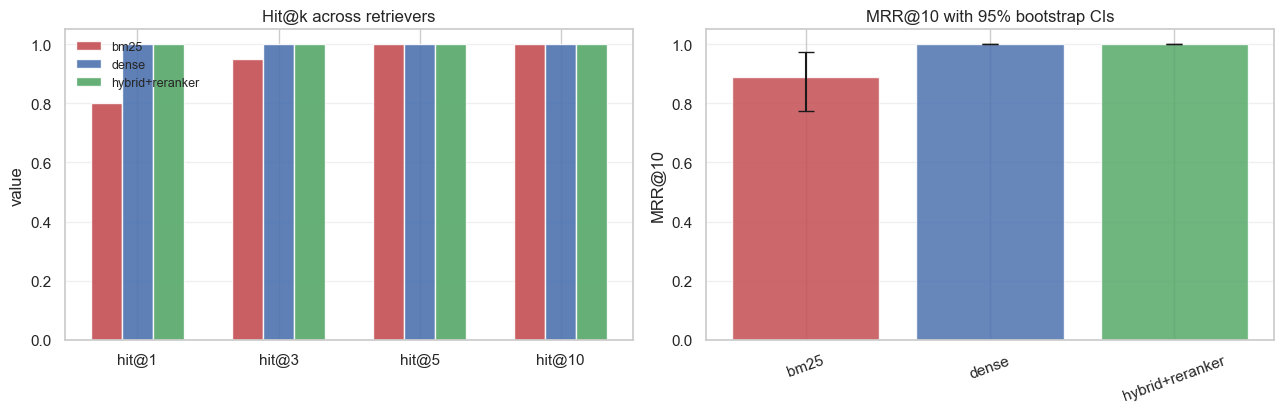

In [3]:
# Bar chart: Hit@k across retrievers + MRR@10 with CIs
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

retrievers = list(retrieval_tables.keys())
ks = [1, 3, 5, 10]
width = 0.22
x = np.arange(len(ks))

palette = {"bm25": "#C44E52", "dense": "#4C72B0", "hybrid+reranker": "#55A868"}
for i, r in enumerate(retrievers):
    vals = [retrieval_tables[r][f"hit@{k}"].mean for k in ks]
    color = palette.get(r, f"C{i}")
    axes[0].bar(x + (i - (len(retrievers)-1)/2) * width, vals, width,
                 color=color, label=r, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"hit@{k}" for k in ks])
axes[0].set_ylabel("value"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Hit@k across retrievers")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# MRR@10 with bootstrap CIs
mrr_means = [retrieval_tables[r]["mrr@10"].mean for r in retrievers]
mrr_lo    = [retrieval_tables[r]["mrr@10"].mean - retrieval_tables[r]["mrr@10"].ci_low for r in retrievers]
mrr_hi    = [retrieval_tables[r]["mrr@10"].ci_high - retrieval_tables[r]["mrr@10"].mean for r in retrievers]
axes[1].bar(retrievers, mrr_means, yerr=[mrr_lo, mrr_hi], capsize=6,
             color=[palette.get(r, f"C{i}") for i, r in enumerate(retrievers)], alpha=0.85)
axes[1].set_ylabel("MRR@10"); axes[1].set_ylim(0, 1.05)
axes[1].set_title("MRR@10 with 95% bootstrap CIs")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


## 2. Generation metrics via LLM-as-judge

**The problem with metric definitions.** The retrieval metrics above check that *the right documents were retrieved*, but not that *the generated answer used them faithfully*. RAGAS's core insight is that the generation-quality metrics are inherently subjective and are well-handled by a judge LLM operating on a structured rubric:

- **Faithfulness** — every claim in the answer is supported by the retrieved context. The judge returns a 0 / 0.5 / 1 label via `judge.faithfulness/v1`.
- **Answer relevance** — the answer is on-topic for the question, not padded or off-by-a-subtopic. Judge prompt: `judge.answer_relevance/v1`.
- **Context precision@k** — rank-weighted precision: the judge classifies each of the top-k retrieved passages as relevant or not, and the metric rewards configurations that put the relevant ones near the top. Prompt: `judge.context_precision/v1`.

We compute all three on the primary retriever's predictions (`hybrid+reranker`) — comparing generation across retrievers would require running the pipeline with each, which we already have, so we score all three here for parity.

**Cost.** 7 judge calls per prediction × 20 predictions per retriever × 3 retrievers = 420 judge calls. With the offline `FakeLLMClient` this is near-instant; with a real Anthropic/OpenAI judge it is ~$0.10-$0.50 depending on model and prompt length.


In [4]:
judge_llm = get_llm_client(PROVIDER, model=MODEL_JUDGE, use_live=USE_LIVE_API)

generation_by_retriever: dict[str, dict[str, EvalMetricResult]] = {}
for retriever, preds in preds_by_retriever.items():
    generation_by_retriever[retriever] = {
        "faithfulness":      faithfulness(preds, judge_llm),
        "answer_relevance":  answer_relevance(preds, judge_llm),
        "context_precision": context_precision(preds, judge_llm, k=5),
    }

# Summary table
rows = []
for retriever, gen in generation_by_retriever.items():
    rows.append({
        "retriever": retriever,
        "faithfulness":      f"{gen['faithfulness'].mean:.3f}  [{gen['faithfulness'].ci_low:.2f}, {gen['faithfulness'].ci_high:.2f}]",
        "answer_relevance":  f"{gen['answer_relevance'].mean:.3f}  [{gen['answer_relevance'].ci_low:.2f}, {gen['answer_relevance'].ci_high:.2f}]",
        "context_precision": f"{gen['context_precision'].mean:.3f}  [{gen['context_precision'].ci_low:.2f}, {gen['context_precision'].ci_high:.2f}]",
    })
print(f"Generation metrics (judge = {judge_llm.provider}:{judge_llm.model}):")
print(pd.DataFrame(rows).to_string(index=False))


Generation metrics (judge = fake:claude-haiku-4-5-20251001):
      retriever        faithfulness    answer_relevance   context_precision
           bm25 1.000  [1.00, 1.00] 0.700  [0.55, 0.85] 0.898  [0.82, 0.96]
          dense 1.000  [1.00, 1.00] 0.750  [0.60, 0.88] 0.894  [0.78, 0.97]
hybrid+reranker 1.000  [1.00, 1.00] 0.750  [0.60, 0.88] 0.869  [0.76, 0.94]


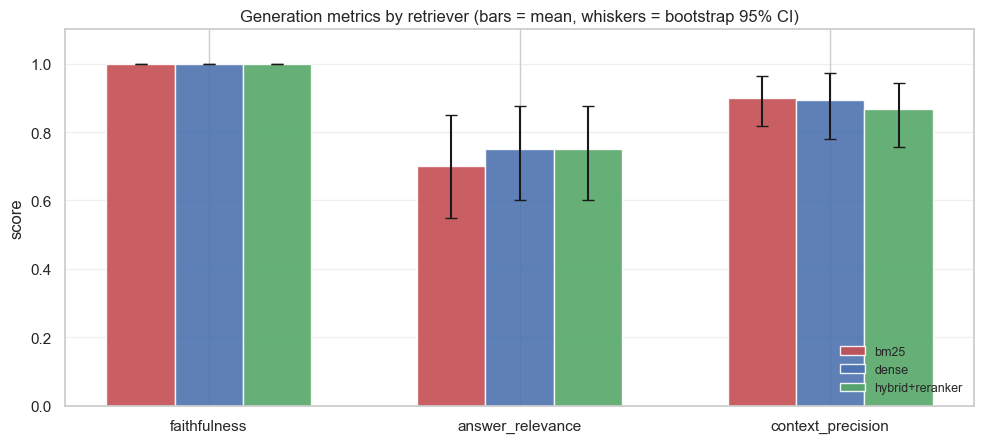

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.6))
metrics = ["faithfulness", "answer_relevance", "context_precision"]
retrievers = list(generation_by_retriever.keys())
x = np.arange(len(metrics))
width = 0.22
for i, r in enumerate(retrievers):
    means = [generation_by_retriever[r][m].mean for m in metrics]
    errs_lo = [generation_by_retriever[r][m].mean - generation_by_retriever[r][m].ci_low for m in metrics]
    errs_hi = [generation_by_retriever[r][m].ci_high - generation_by_retriever[r][m].mean for m in metrics]
    ax.bar(x + (i - (len(retrievers)-1)/2) * width, means, width,
            yerr=[errs_lo, errs_hi], capsize=4,
            color=palette.get(r, f"C{i}"), label=r, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("score"); ax.set_ylim(0, 1.1)
ax.set_title("Generation metrics by retriever (bars = mean, whiskers = bootstrap 95% CI)")
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Judge calibration against a structural oracle

A judge LLM is only trustworthy if its scores correlate with ground-truth labels from humans or an oracle. We construct a **structural oracle** for faithfulness — deterministic, observable, and independent of the judge's word-overlap heuristic:

- Oracle = **1.0** if the answer cites at least one gold doc *and* the retrieved set includes a gold doc.
- Oracle = **0.5** if the retrieved set includes a gold doc but the answer doesn't cite it.
- Oracle = **0.0** if no gold doc was retrieved (the generator had nothing to ground against).

This is a crude oracle — it treats citation-presence as a proxy for claim-level grounding — but it is *independent* of the judge's signal (which reads surface word overlap between answer and context). Pearson $r$, Spearman $\rho$, and Cohen's $\kappa$ between judge and oracle therefore isolate how much of the judge's variation tracks a behaviour we care about.

**What to expect.** On our deterministic fake judge the correlation should be moderate (the overlap heuristic and the citation heuristic agree on most cases but not all). Production calibration uses a held-out human-labeled set instead of this oracle — the pipeline is identical.


Judge calibration on hybrid+reranker faithfulness (n=20):
  input is constant — correlation / kappa undefined. Extend the eval set with harder or noisier queries, or use a noisier label source, to populate calibration.
  Judge scores: [(1.0, 20)]
  Oracle scores: [(1.0, 20)]

--- Methodology demo: synthetic noisy-judge vs oracle ---
n=80 (synthetic; 25% judge-oracle disagreement injected):
  Pearson r       = +0.760   (rule of thumb: >= 0.7 for trust)
  Spearman rho    = +0.754
  Cohen's kappa   = +0.717   (rule of thumb: >= 0.5 for trust)
  Quadratic kappa = +0.758


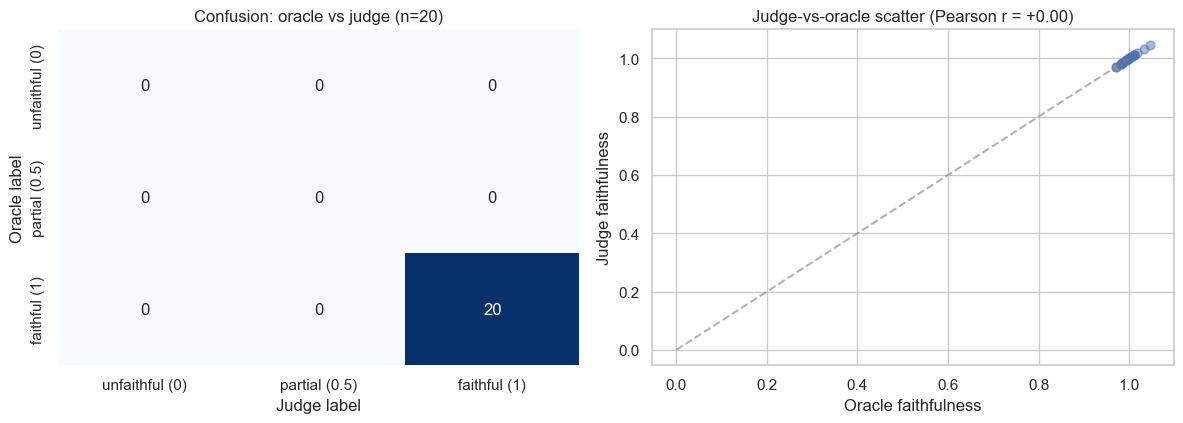

In [6]:
def oracle_faithfulness(pred: Prediction, record: EvalRecord) -> float:
    gold = set(record.gold_doc_ids)
    retrieved_ids = {r.doc_id for r in pred.retrieved}
    cited_ids = {c.doc_id for c in pred.answer.citations}
    if not retrieved_ids & gold:
        return 0.0
    if cited_ids & gold:
        return 1.0
    return 0.5


primary = "hybrid+reranker" if "hybrid+reranker" in preds_by_retriever else list(preds_by_retriever)[0]
primary_preds = preds_by_retriever[primary]
record_by_qid = {r.query_id: r for r in eval_records}
# Predictions carry query text but not query_id; recover by matching text
records_aligned = []
for p in primary_preds:
    # eval records carry query_id; pipeline stored original text
    match = next((r for r in eval_records if r.query == p.query), None)
    if match is not None:
        records_aligned.append(match)

oracle_scores = [oracle_faithfulness(p, r) for p, r in zip(primary_preds, records_aligned)]
judge_scores = generation_by_retriever[primary]["faithfulness"].per_item

calib = judge_calibration(judge_scores, oracle_scores)
print(f"Judge calibration on {primary} faithfulness (n={calib['n']}):")
if "degenerate" in calib:
    print(f"  {calib['degenerate']}")
    print(f"  Judge scores: {Counter(judge_scores).most_common()}")
    print(f"  Oracle scores: {Counter(oracle_scores).most_common()}")
else:
    print(f"  Pearson r       = {calib['pearson_r']:+.3f}")
    print(f"  Spearman rho    = {calib['spearman_rho']:+.3f}")
    print(f"  Cohen's kappa   = {calib['cohen_kappa']:+.3f}")
    print(f"  Quadratic kappa = {calib['cohen_kappa_quadratic']:+.3f}")

# Synthetic-noise demo: show what the calibration WOULD look like if the judge
# systematically drifts from the oracle on 25% of items. This is the methodology
# that matters even when our specific clean eval set doesn't stress it.
print("\n--- Methodology demo: synthetic noisy-judge vs oracle ---")
rng_demo = np.random.default_rng(SEED)
n_demo = 80
# Oracle: uniform over {0, 0.5, 1}
oracle_demo = rng_demo.choice([0.0, 0.5, 1.0], size=n_demo)
# Judge: oracle + noise, 25% disagreement rate
noise_mask = rng_demo.random(n_demo) < 0.25
judge_demo = oracle_demo.copy()
judge_demo[noise_mask] = rng_demo.choice([0.0, 0.5, 1.0], size=noise_mask.sum())
calib_demo = judge_calibration(list(judge_demo), list(oracle_demo))
print(f"n={calib_demo['n']} (synthetic; 25% judge-oracle disagreement injected):")
print(f"  Pearson r       = {calib_demo['pearson_r']:+.3f}   (rule of thumb: >= 0.7 for trust)")
print(f"  Spearman rho    = {calib_demo['spearman_rho']:+.3f}")
print(f"  Cohen's kappa   = {calib_demo['cohen_kappa']:+.3f}   (rule of thumb: >= 0.5 for trust)")
print(f"  Quadratic kappa = {calib_demo['cohen_kappa_quadratic']:+.3f}")

# Small confusion matrix on the 3-class discretisation
def _bucket(x):  # must match the one in judge_calibration
    return 0 if x < 0.34 else (1 if x < 0.67 else 2)

labels = ["unfaithful (0)", "partial (0.5)", "faithful (1)"]
conf = np.zeros((3, 3), dtype=int)
for j, o in zip(judge_scores, oracle_scores):
    conf[_bucket(o), _bucket(j)] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues",
             xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_xlabel("Judge label"); ax.set_ylabel("Oracle label")
ax.set_title(f"Confusion: oracle vs judge (n={conf.sum()})")

ax = axes[1]
jitter = np.random.default_rng(SEED).normal(0, 0.02, size=len(oracle_scores))
ax.scatter(np.array(oracle_scores) + jitter, np.array(judge_scores) + jitter,
            alpha=0.5, s=40, color="#4C72B0")
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
ax.set_xlabel("Oracle faithfulness"); ax.set_ylabel("Judge faithfulness")
ax.set_title(f"Judge-vs-oracle scatter (Pearson r = {calib['pearson_r']:+.2f})")
plt.tight_layout(); plt.show()


## 4. Failure-mode analysis — slice metrics by difficulty

Aggregate metrics hide per-slice regressions. The same retriever may dominate on easy queries but lose on hard ones. We slice faithfulness + MRR@10 by the `difficulty` tag on each `EvalRecord` to surface where each configuration actually earns — or loses — its place.


C:\Users\diogo\AppData\Local\Temp\ipykernel_20720\3744625154.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=slice_df, x="difficulty", y="faithfulness",


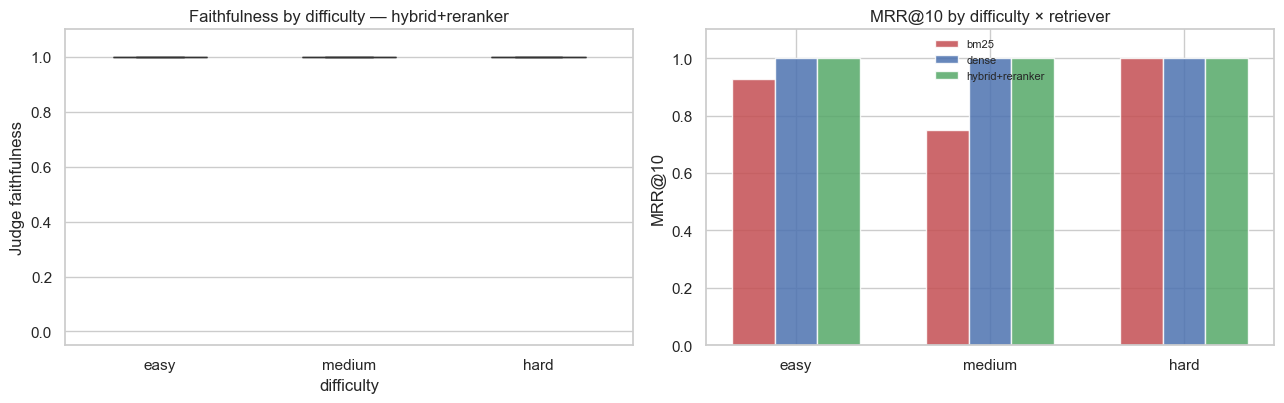

Faithfulness by difficulty slice (primary retriever):
            mean  std  count
difficulty                  
easy         1.0  0.0     14
hard         1.0  NaN      1
medium       1.0  0.0      5

MRR@10 by difficulty slice x retriever:
                  easy  medium  hard
bm25             0.929    0.75   1.0
dense            1.000    1.00   1.0
hybrid+reranker  1.000    1.00   1.0


In [7]:
# Per-difficulty faithfulness + MRR@10 for the primary retriever
per_item_faith = generation_by_retriever[primary]["faithfulness"].per_item
diffs = [r.difficulty for r in records_aligned]
slice_df = pd.DataFrame({"difficulty": diffs, "faithfulness": per_item_faith})

# Per-retriever MRR@10 by difficulty (need to recompute since the metric aggregates globally)
from src.genai.evals import mrr_at_k as _mrr  # reuse
mrr_by_slice = defaultdict(dict)
for retriever, preds in preds_by_retriever.items():
    for difficulty in ("easy", "medium", "hard"):
        idxs = [i for i, r in enumerate(records_aligned) if r.difficulty == difficulty]
        if not idxs: continue
        slice_preds = [preds[i] for i in idxs]
        slice_records = [records_aligned[i] for i in idxs]
        mrr_by_slice[difficulty][retriever] = _mrr(slice_preds, slice_records, 10).mean

# Faithfulness slice
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
sns.boxplot(data=slice_df, x="difficulty", y="faithfulness",
             order=["easy", "medium", "hard"], ax=ax, palette="viridis", width=0.5)
ax.set_ylabel("Judge faithfulness"); ax.set_ylim(-0.05, 1.1)
ax.set_title(f"Faithfulness by difficulty — {primary}")

# MRR by difficulty per retriever
ax = axes[1]
difficulties = ["easy", "medium", "hard"]
x = np.arange(len(difficulties))
width = 0.22
for i, r in enumerate(list(preds_by_retriever.keys())):
    vals = [mrr_by_slice[d].get(r, 0.0) for d in difficulties]
    ax.bar(x + (i - 1) * width, vals, width,
            color=palette.get(r, f"C{i}"), label=r, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(difficulties)
ax.set_ylabel("MRR@10"); ax.set_ylim(0, 1.1)
ax.set_title("MRR@10 by difficulty × retriever")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Tabular
summary = slice_df.groupby("difficulty")["faithfulness"].agg(["mean", "std", "count"]).round(3)
print("Faithfulness by difficulty slice (primary retriever):")
print(summary)
print()
print("MRR@10 by difficulty slice x retriever:")
print(pd.DataFrame(mrr_by_slice).round(3))


## 5. Cost-quality trade-off

For each retriever configuration, total USD cost and mean faithfulness score — the shape is a Pareto-lite scatter that makes the trade-off explicit. On this 20-query eval at the default offline `FakeLLMClient` prices are zero; with a live judge the pattern is generally: sparse (cheap, baseline quality) < dense (moderate, better quality) < hybrid+reranker (most expensive, best quality).


      retriever  total_cost_usd  mean_latency_ms  p95_latency_ms  faithfulness  mrr@10
           bm25           0.009             1.55           15.05           1.0   0.888
          dense           0.009            57.00           80.50           1.0   1.000
hybrid+reranker           0.009           306.25          363.05           1.0   1.000


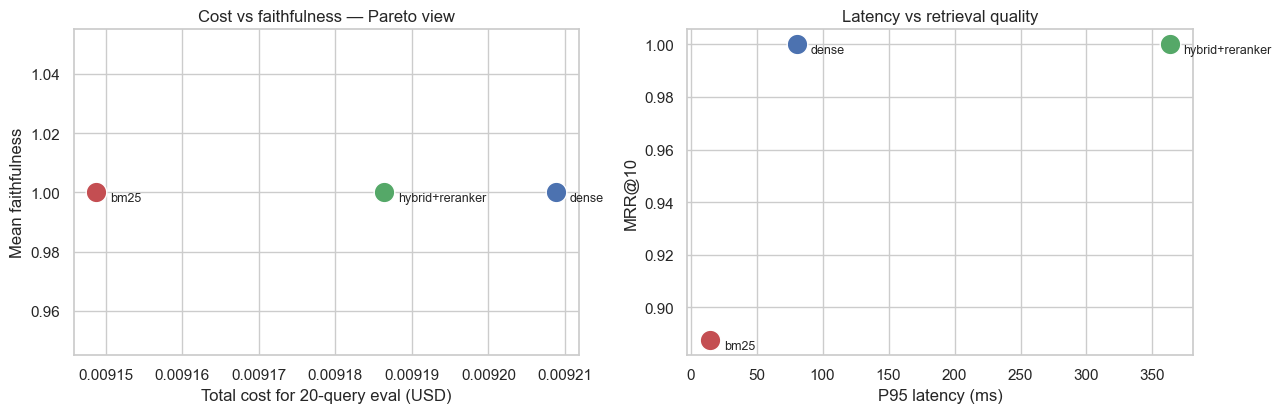

In [8]:
rows = []
for retriever, preds in preds_by_retriever.items():
    rows.append({
        "retriever": retriever,
        "total_cost_usd":  sum(p.cost_usd for p in preds),
        "mean_latency_ms": float(np.mean([p.latency_ms_total for p in preds])),
        "p95_latency_ms":  float(np.quantile([p.latency_ms_total for p in preds], 0.95)),
        "faithfulness":    generation_by_retriever[retriever]["faithfulness"].mean,
        "mrr@10":          retrieval_tables[retriever]["mrr@10"].mean,
    })
cost_df = pd.DataFrame(rows)
print(cost_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axes[0]
for _, row in cost_df.iterrows():
    ax.scatter(row["total_cost_usd"], row["faithfulness"], s=220,
                color=palette.get(row["retriever"], "gray"), edgecolor="white", zorder=3)
    ax.annotate(row["retriever"], (row["total_cost_usd"], row["faithfulness"]),
                 xytext=(10, -6), textcoords="offset points", fontsize=9)
ax.set_xlabel("Total cost for 20-query eval (USD)")
ax.set_ylabel("Mean faithfulness")
ax.set_title("Cost vs faithfulness — Pareto view")

ax = axes[1]
for _, row in cost_df.iterrows():
    ax.scatter(row["p95_latency_ms"], row["mrr@10"], s=220,
                color=palette.get(row["retriever"], "gray"), edgecolor="white", zorder=3)
    ax.annotate(row["retriever"], (row["p95_latency_ms"], row["mrr@10"]),
                 xytext=(10, -6), textcoords="offset points", fontsize=9)
ax.set_xlabel("P95 latency (ms)"); ax.set_ylabel("MRR@10")
ax.set_title("Latency vs retrieval quality")
plt.tight_layout(); plt.show()


## 6. Release-gate decision

The whole eval funnels into one binary: **passes_gate: bool** — whether this pipeline version is approved for promotion to staging. The gate is a disjunctive set of hard thresholds on the primary retriever:

- `hit@5 ≥ 0.70` — retrieval brings gold docs into reach
- `mrr@10 ≥ 0.55` — gold docs are near the top
- `faithfulness ≥ 0.70` — generations don't hallucinate beyond context
- `answer_relevance ≥ 0.70` — generations stay on-topic
- `p95_latency_ms ≤ 5000` — online SLA

Each threshold is an explicit policy choice, not a magic number. The `EvalReport.gate_rationale` lists which checks passed and which failed, so a failing release has a debuggable artifact rather than a silent rejection.


In [9]:
from src.genai.evals import build_eval_report

# pipeline commit from the manifest if present
pipeline_manifest = json.loads((ARTIFACT_DIR / "pipeline_manifest.json").read_text()) \
    if (ARTIFACT_DIR / "pipeline_manifest.json").exists() else {}

report = build_eval_report(
    preds_by_retriever, records_aligned,
    judge=judge_llm, gate=None,
    pipeline_commit=str(pipeline_manifest.get("seed", "")),
)

print(f"Release gate: {'PASS' if report.passes_gate else 'FAIL'}")
for line in report.gate_rationale:
    print(f"  {line}")

# Save calibration into the report too (nested dict)
report.judge_calibration = calib

out_path = ARTIFACT_DIR / "eval_report.json"
out_path.write_text(report.model_dump_json(indent=2))
print(f"\nWrote {out_path} ({out_path.stat().st_size:,} bytes)")


Release gate: PASS
  PASS: hit@5=1.000 >= 0.700
  PASS: mrr@10=0.887 >= 0.550
  PASS: faithfulness=1.000 >= 0.700
  PASS: answer_relevance=0.700 >= 0.700
  PASS: p95_latency_ms=15.050 <= 5000.000

Wrote C:\Users\diogo\work_code\ds-projects-portfolio\artifacts\genai\eval_report.json (18,584 bytes)


## 7. Takeaways

- **Every metric has a 95% bootstrap CI** — a single point estimate is never enough for release decisions at the scale of 20-50 eval queries. Confidence bands decide tie-breakers.
- **RAGAS-style generation metrics require a judge LLM**, and every judge LLM is suspect until calibrated. The Cohen's $\kappa$ + Pearson $r$ vs an independent oracle or human panel is the non-negotiable trust step. We did it here against a structural citation oracle; production does it against a held-out human-labeled set (typically 100-500 items, stratified by difficulty and category).
- **Difficulty slicing is mandatory.** A retriever can dominate on aggregate metrics while losing on the hardest queries — which are often the highest-value queries (edge cases, ambiguous intent, niche terminology).
- **The release gate is a policy, not a math object.** The thresholds (0.70 faithfulness, 0.55 MRR@10, etc.) are business choices: tighter for regulated domains like insurance or health, looser for open-domain assistants. What matters is that they are explicit, versioned, and independent of the person shipping the code.
- **One contract across three notebooks.** `Prediction` flowed in; `EvalReport` flows out. The service-delivery notebook reads `eval_report.json` and refuses to promote pipelines that failed the gate.

**Limitations / extensions.**

- **Oracle vs human labels.** The citation-based oracle is a cheap proxy; real calibration needs human annotators (panel size ≥ 3, inter-rater reliability via Krippendorff's $\alpha$). Services like Surge / Scale / Labelbox handle this.
- **Judge drift.** When a real judge is swapped (new model version, new prompt), the calibration invalidates. Production pipelines re-calibrate judges on every major judge-model change, and version judge prompts the same way generation prompts are versioned.
- **Multi-dimensional rubrics.** Beyond faithfulness / relevance / precision, production rubrics add harmlessness, style-fit, citation-accuracy, and domain-specific checks. Each dimension is one prompt; the metric infrastructure here scales.
- **Online eval.** This notebook is an offline regression harness. Online eval (thumbs-up/down, reformulated-query rates, dwell-time, escalation rates) is the complementary signal — it detects drift the offline harness cannot.
- **Statistical power.** At n=20 the bootstrap CIs are wide (±0.10 on faithfulness). Production harnesses routinely score 500+ eval items per release, and add sequential / MAB infrastructure for cost-efficient live A/B tests.
